# 02 — Preprocessing
**Referencias:** ESL Cap. 3.4 (Shrinkage) · Géron Cap. 2 (End-to-End Project)

## ¿Por qué preprocesar?
La mayoría de algoritmos asumen features en escala comparable. Además (Géron):
- Gradient Descent converge mucho más rápido con features escaladas
- Algoritmos basados en distancia (KNN, SVM, K-Means) son muy sensibles a escala
- Los árboles de decisión son los únicos que no lo necesitan

## Data Leakage — el error más costoso
**Fit solo en train.** Si fitas el scaler en todo el dataset, introduces información del futuro
en el modelo → métricas optimistas que no se replican en producción.

In [8]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False, 'font.family': 'Optima',
})
np.random.seed(42)

n = 800
df = pd.DataFrame({
    'sessions':        np.random.randint(1, 20, n),
    'time_on_site':    np.random.uniform(30, 600, n).round(0),
    'pages_per_visit': np.random.uniform(1, 8, n).round(2),
    'days_since_reg':  np.random.randint(0, 30, n),
    'revenue':         np.abs(np.random.normal(500, 200, n)),  # con outliers
    'channel':         np.random.choice(['organic','paid','email','direct'], n),
    'device':          np.random.choice(['mobile','desktop','tablet'], n),
    'activated':       np.random.choice([0, 1], n, p=[0.7, 0.3]),
})
# Introducir outliers en revenue
df.loc[np.random.choice(n, 15, replace=False), 'revenue'] = np.random.uniform(5000, 15000, 15)
# Introducir nulls
idx = np.random.choice(n, 80, replace=False)
df.loc[idx[:40], 'time_on_site']    = np.nan
df.loc[idx[40:], 'pages_per_visit'] = np.nan

print('Shape:', df.shape)
print('Nulls:\n', df.isnull().sum())
df.head()

Shape: (800, 8)
Nulls:
 sessions            0
time_on_site       40
pages_per_visit    40
days_since_reg      0
revenue             0
channel             0
device              0
activated           0
dtype: int64


,sessions,time_on_site,pages_per_visit,days_since_reg,revenue,channel,device,activated
0,7,594.0,NaN,8,534.518821,direct,desktop,1
1,15,214.0,5.06,23,411.454990,organic,tablet,1
2,11,492.0,4.74,4,530.323765,email,mobile,1
3,8,175.0,5.26,16,505.085341,paid,mobile,0
4,7,418.0,6.35,8,537.560510,email,desktop,0


## 1 — Scalers: cuándo usar cada uno (Géron Cap. 2)

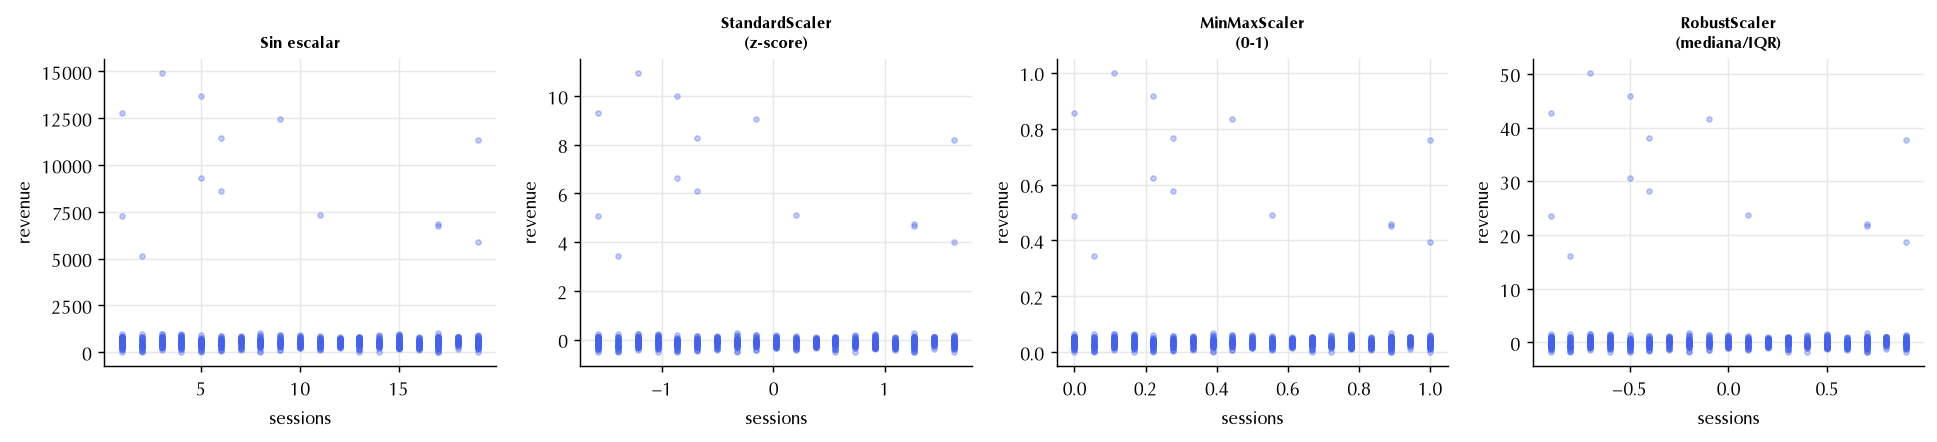

StandardScaler: úsalo por default — asume distribución ~Normal
MinMaxScaler:   úsalo cuando necesitas rango fijo (ej. imágenes 0-255→0-1)
RobustScaler:   úsalo cuando tienes outliers — usa mediana e IQR en lugar de media/std


In [9]:
X_num = df[['sessions', 'time_on_site', 'revenue']].dropna()

scalers = [
    ('Sin escalar',    None),
    ('StandardScaler\n(z-score)',  StandardScaler()),
    ('MinMaxScaler\n(0-1)',        MinMaxScaler()),
    ('RobustScaler\n(mediana/IQR)', RobustScaler()),  # robusto a outliers
]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, (name, scaler) in zip(axes, scalers):
    if scaler is None:
        X_plot = X_num[['sessions','revenue']].values
    else:
        X_plot = scaler.fit_transform(X_num[['sessions','revenue']])
    ax.scatter(X_plot[:,0], X_plot[:,1], alpha=0.3, s=8, color='#4361ee')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('sessions')
    ax.set_ylabel('revenue')

plt.tight_layout()
plt.show()

print('StandardScaler: úsalo por default — asume distribución ~Normal')
print('MinMaxScaler:   úsalo cuando necesitas rango fijo (ej. imágenes 0-255→0-1)')
print('RobustScaler:   úsalo cuando tienes outliers — usa mediana e IQR en lugar de media/std')

## 2 — Imputers: SimpleImputer vs KNNImputer

In [10]:
X_miss = df[['sessions', 'time_on_site', 'pages_per_visit', 'days_since_reg']].copy()
print('Nulls por columna:')
print(X_miss.isnull().sum())

# SimpleImputer: rápido, no usa otras features
simple = SimpleImputer(strategy='median')
X_simple = simple.fit_transform(X_miss)

# KNNImputer (Géron): usa los k vecinos más cercanos para imputar
# Más preciso cuando hay correlación entre features, más lento
knn_imp = KNNImputer(n_neighbors=5)
X_knn   = knn_imp.fit_transform(X_miss)

print(f'\nNulls después de SimpleImputer: {np.isnan(X_simple).sum()}')
print(f'Nulls después de KNNImputer:    {np.isnan(X_knn).sum()}')
print()
print('Valores imputados en time_on_site:')
idx_null = X_miss['time_on_site'].isnull()
comp = pd.DataFrame({
    'SimpleImputer (mediana)': X_simple[idx_null, 1][:5].round(1),
    'KNNImputer (k=5)':        X_knn[idx_null, 1][:5].round(1),
})
print(comp.to_string(index=False))

Nulls por columna:
sessions            0
time_on_site       40
pages_per_visit    40
days_since_reg      0
dtype: int64

Nulls después de SimpleImputer: 0
Nulls después de KNNImputer:    0

Valores imputados en time_on_site:
 SimpleImputer (mediana)  KNNImputer (k=5)
                   326.0             239.0
                   326.0             333.2
                   326.0             250.6
                   326.0             460.4
                   326.0             386.2


## 3 — Custom Transformer (Géron Cap. 2)
Cuando las transformaciones predefinidas no alcanzan, crea las tuyas.
Hereda de `BaseEstimator` + `TransformerMixin` para que funcione dentro de Pipelines y GridSearch.

In [11]:
class EngagementScoreTransformer(BaseEstimator, TransformerMixin):
    """
    Feature engineering dentro del pipeline.
    Combina sessions + pages_per_visit en un engagement_score.
    """
    def __init__(self, sessions_weight=0.4, pages_weight=0.6):
        self.sessions_weight = sessions_weight
        self.pages_weight    = pages_weight

    def fit(self, X, y=None):
        return self   # sin estado que aprender

    def transform(self, X, y=None):
        X_    = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        X_['engagement_score'] = (
            X_.iloc[:, 0] * self.sessions_weight +    # sessions
            X_.iloc[:, 2] * self.pages_weight          # pages_per_visit
        )
        return X_.values


# Probar en el pipeline
X_demo = df[['sessions', 'time_on_site', 'pages_per_visit', 'days_since_reg']].dropna()
transformer = EngagementScoreTransformer(sessions_weight=0.4, pages_weight=0.6)
X_transformed = transformer.fit_transform(X_demo)

print('Shape original:', X_demo.shape)
print('Shape transformado:', X_transformed.shape)
print('Primeras filas (última columna = engagement_score):')
print(pd.DataFrame(X_transformed, columns=['sessions','time_on_site','pages','days_reg','engagement']).head(4).round(2))

Shape original: (720, 4)
Shape transformado: (720, 5)
Primeras filas (última columna = engagement_score):
   sessions  time_on_site  pages  days_reg  engagement
0      15.0         214.0   5.06      23.0        9.04
1      11.0         492.0   4.74       4.0        7.24
2       8.0         175.0   5.26      16.0        6.36
3       7.0         418.0   6.35       8.0        6.61


## 4 — Feature Selection (ESL Cap. 3.3 / Géron Cap. 6)
Eliminar features irrelevantes reduce varianza y acelera el entrenamiento.

In [12]:
# Generar dataset con features irrelevantes
X_sel = df[['sessions','time_on_site','pages_per_visit','days_since_reg']].fillna(df.mean(numeric_only=True))
# Agregar ruido puro (features inútiles)
for i in range(5):
    X_sel[f'noise_{i}'] = np.random.normal(0, 1, len(X_sel))
y_sel = df['activated']

print(f'Features totales: {X_sel.shape[1]}')

# --- Método 1: VarianceThreshold — elimina features con varianza casi nula ---
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_sel)
print(f'VarianceThreshold: {vt.get_support().sum()} features mantenidas')

# --- Método 2: SelectKBest — selecciona k mejores por test estadístico ---
skb = SelectKBest(score_func=f_classif, k=4)
skb.fit(X_sel, y_sel)
scores = pd.Series(skb.scores_, index=X_sel.columns).sort_values(ascending=False)
print(f'\nSelectKBest — F-scores (ANOVA):')
print(scores.round(2).to_string())

# --- Método 3: RFE — Recursive Feature Elimination (Géron) ---
rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=4)
rfe.fit(X_sel, y_sel)
rfe_support = pd.Series(rfe.support_, index=X_sel.columns)
print(f'\nRFE — features seleccionadas:')
print(rfe_support[rfe_support].index.tolist())

Features totales: 9
VarianceThreshold: 9 features mantenidas

SelectKBest — F-scores (ANOVA):
noise_0            5.85
sessions           4.34
time_on_site       1.61
noise_3            1.49
days_since_reg     0.42
noise_1            0.21
pages_per_visit    0.12
noise_2            0.06
noise_4            0.03

RFE — features seleccionadas:
['noise_0', 'noise_2', 'noise_3', 'noise_4']


## 5 — ColumnTransformer + Pipeline completo

In [13]:
num_features = ['sessions', 'time_on_site', 'pages_per_visit', 'days_since_reg']
cat_features = ['channel', 'device']

num_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  RobustScaler()),     # robusto si hay outliers en tus datos
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features),
])

X = df[num_features + cat_features]
y = df['activated']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit solo en train
X_tr_prep = preprocessor.fit_transform(X_train)
X_te_prep = preprocessor.transform(X_test)

cat_names = list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out())
all_names = num_features + cat_names

print('Shape original:', X_train.shape)
print('Shape preprocesado:', X_tr_prep.shape)
print('Columnas:', all_names)

Shape original: (640, 6)
Shape preprocesado: (640, 11)
Columnas: ['sessions', 'time_on_site', 'pages_per_visit', 'days_since_reg', 'x0_direct', 'x0_email', 'x0_organic', 'x0_paid', 'x1_desktop', 'x1_mobile', 'x1_tablet']


## Resumen

| Herramienta | Cuándo | Referencia |
|---|---|---|
| `StandardScaler` | Default para la mayoría de algoritmos | Géron Cap. 2 |
| `RobustScaler` | Datos con outliers (ej. revenue) | Géron Cap. 2 |
| `KNNImputer` | Nulls con correlación entre features | Géron Cap. 2 |
| `BaseEstimator + TransformerMixin` | Feature engineering personalizado dentro de Pipeline | Géron Cap. 2 |
| `SelectKBest` / `RFE` | Reducir dimensionalidad, eliminar ruido | ESL 3.3 / Géron Cap. 6 |
| `.fit()` solo en train | Evitar data leakage | Géron Cap. 2 |

**Siguiente:** `03_regression.ipynb`